<a href="https://colab.research.google.com/github/AngeloSorte/Solar-Flare-Prediction-with-LSTM-Time-Series-Forecasting-/blob/angelosorte.github.io/Solar_Flare_Prediction_with_LSTM_(Time_Series_Forecasting).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.1243 - val_loss: 0.0189
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0228 - val_loss: 0.0175
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0196 - val_loss: 0.0176
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0186 - val_loss: 0.0175
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0185 - val_loss: 0.0179


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


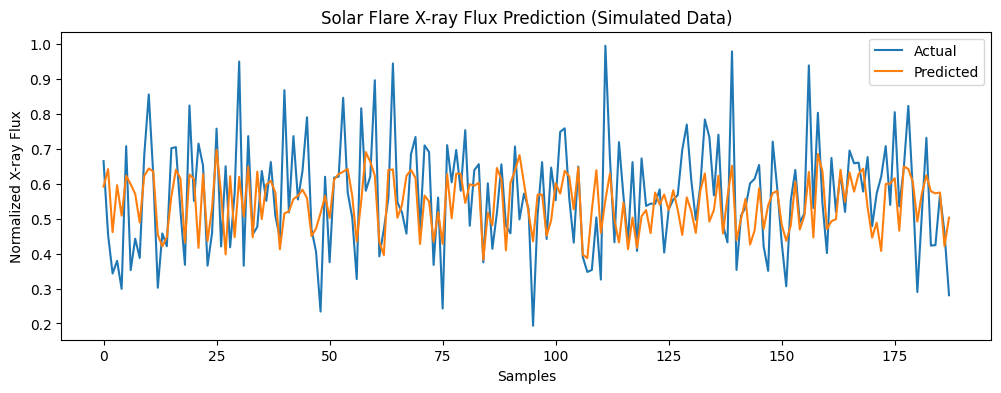

In [ ]:
# ===============================================
# Solar Flare Prediction with LSTM
# Time Series Forecasting (SIMULATED DATA)
# Fully Colab-compatible – single cell
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1️⃣ Simulate X-ray flux data (1000 minutes)
# This simulates solar activity patterns similar to GOES X-ray measurements
np.random.seed(42)
time = np.arange(1000)
flux = 0.5 + 0.05 * np.sin(0.02 * time) + 0.05 * np.random.randn(1000)
flux = flux.reshape(-1, 1)

# 2️⃣ Normalize data to [0,1]
scaler = MinMaxScaler()
data = scaler.fit_transform(flux)

# 3️⃣ Create LSTM sequences
# Use the last 60 minutes to predict the next value
SEQ_LENGTH = 60

def create_sequences(data, seq_length=SEQ_LENGTH):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data)

# 4️⃣ Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Define LSTM model
model = Sequential([
    LSTM(50, input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

# 6️⃣ Train the model
model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=16,
    verbose=1
)

# 7️⃣ Predict on validation set
preds = model.predict(X_val)

# 8️⃣ Visualization: real vs predicted X-ray flux
plt.figure(figsize=(12, 4))
plt.plot(y_val[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.title("Solar Flare X-ray Flux Prediction (Simulated Data)")
plt.xlabel("Samples")
plt.ylabel("Normalized X-ray Flux")
plt.legend()
plt.show()
